In [1]:
import pandas as pd

f = "Apple Stock Prices (1981 to 2023).csv"   # <-- edit to your exact filename (check the 📁 sidebar in Colab)
df = pd.read_csv(f)

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nData types:\n", df.dtypes)
df.head()

Shape: (10608, 7)

Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Data types:
 Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


In [2]:
# ── Step 1: Initial data exploration ──────────────────────────
import pandas as pd

# Parse Date as day/month/year, then make it the index (time series)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)
df = df.sort_values("Date").set_index("Date")

print("=== Shape ===")
print(df.shape)

print("\n=== Date range ===")
print(df.index.min(), "→", df.index.max())

print("\n=== Null values per column ===")
print(df.isnull().sum())

print("\n=== Data types ===")
print(df.dtypes)

print("\n=== Summary of the time index ===")
print("Total trading days:", len(df))
print("Are dates sorted & unique?", df.index.is_monotonic_increasing, "/", df.index.is_unique)

df.head()

=== Shape ===
(10608, 6)

=== Date range ===
1981-01-02 00:00:00 → 2023-01-27 00:00:00

=== Null values per column ===
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

=== Data types ===
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

=== Summary of the time index ===
Total trading days: 10608
Are dates sorted & unique? True / True


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1981-01-02,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1981-01-05,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
1981-01-06,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
1981-01-07,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
1981-01-08,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


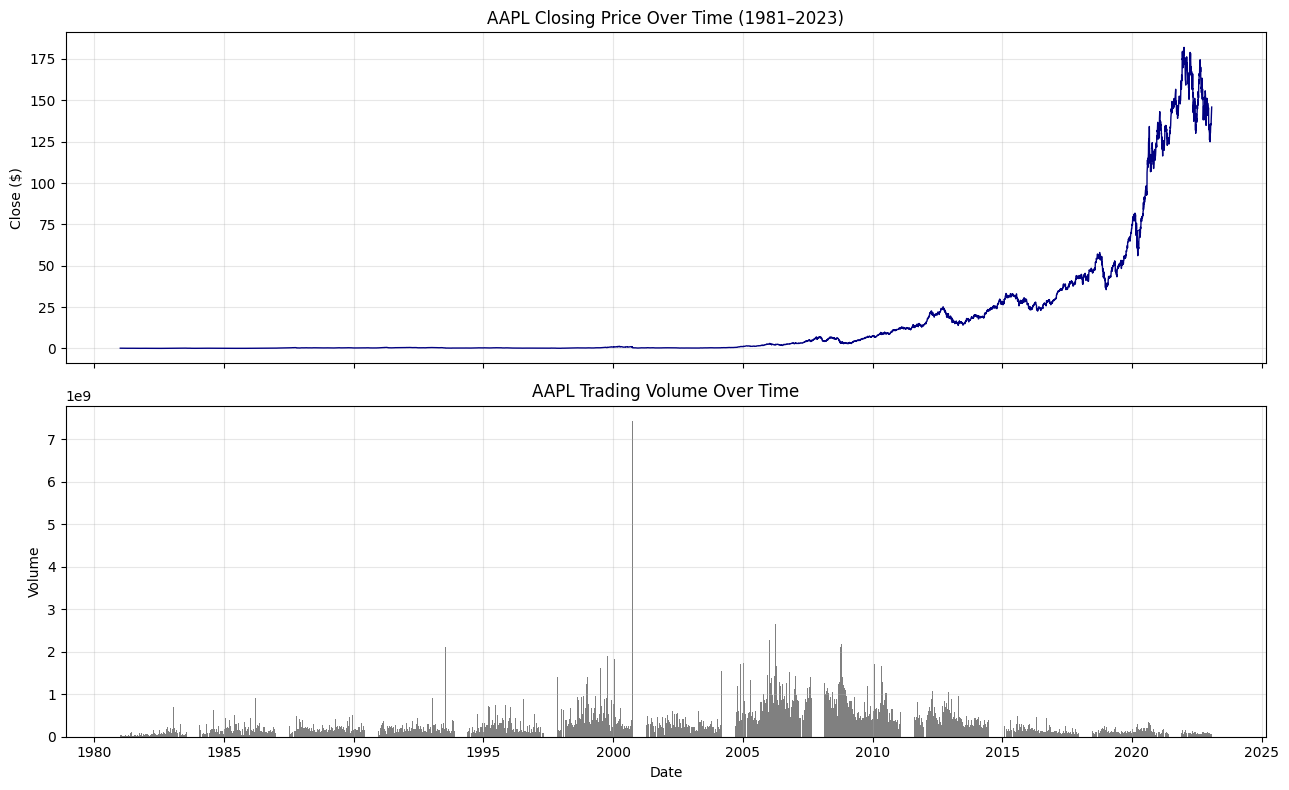

In [3]:
# ── Step 2a: Closing price & volume over time ─────────────────
import matplotlib.pyplot as plt

# Two stacked plots sharing the same x-axis (time)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Closing price
ax1.plot(df.index, df["Close"], color="navy", linewidth=1)
ax1.set_title("AAPL Closing Price Over Time (1981–2023)")
ax1.set_ylabel("Close ($)")
ax1.grid(alpha=0.3)

# Volume
ax2.bar(df.index, df["Volume"], color="gray", width=2)
ax2.set_title("AAPL Trading Volume Over Time")
ax2.set_ylabel("Volume")
ax2.set_xlabel("Date")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# ── Step 2b: install mplfinance ───────────────────────────────
!pip install mplfinance -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 1.6 MB/s eta 0:00:00


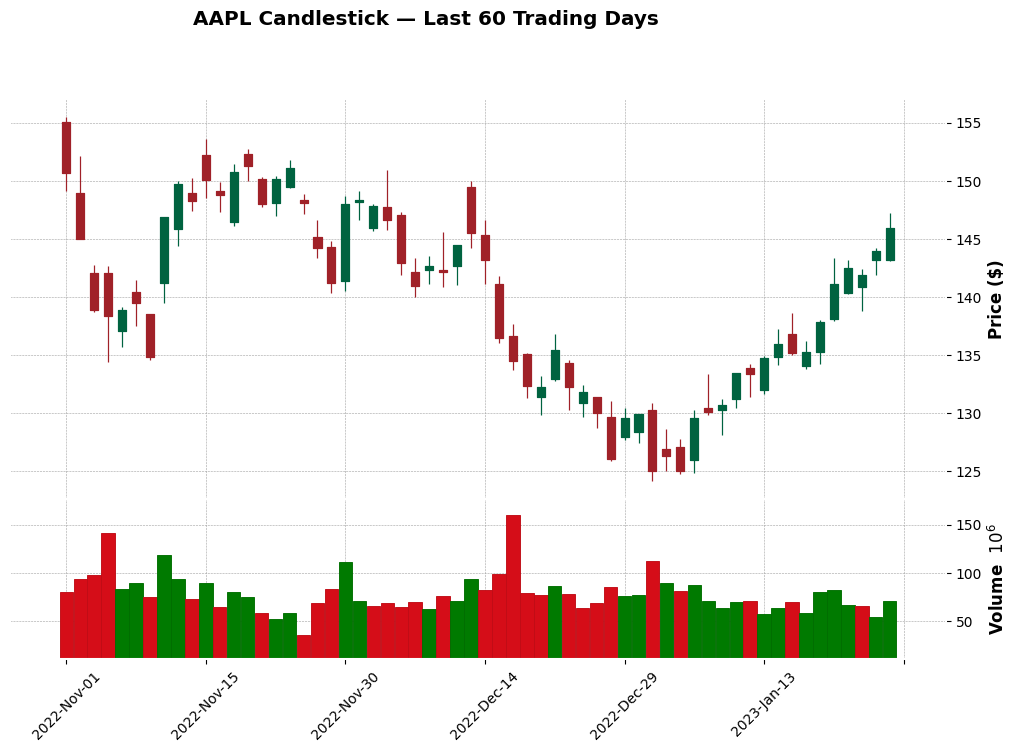

In [5]:
# ── Step 2b: candlestick chart (last ~3 months) ───────────────
import mplfinance as mpf

# Take the most recent 60 trading days so candles are readable
recent = df.tail(60)

mpf.plot(
    recent,
    type="candle",
    style="charles",
    title="AAPL Candlestick — Last 60 Trading Days",
    ylabel="Price ($)",
    volume=True,
    figsize=(13, 8),
)

In [6]:
# ── Step 3a: Summary statistics for key columns ───────────────
key_cols = ["Open", "High", "Low", "Close", "Volume"]

stats = pd.DataFrame({
    "mean":   df[key_cols].mean(),
    "median": df[key_cols].median(),
    "std":    df[key_cols].std(),
    "min":    df[key_cols].min(),
    "max":    df[key_cols].max(),
})
print("=== Summary statistics ===")
print(stats.round(2))

# pandas' built-in describe() as a cross-check
print("\n=== .describe() ===")
print(df[key_cols].describe().round(2))

=== Summary statistics ===
                mean        median           std   min           max
Open    1.669000e+01  4.900000e-01  3.545000e+01  0.05  1.826300e+02
High    1.688000e+01  5.000000e-01  3.588000e+01  0.05  1.829400e+02
Low     1.650000e+01  4.800000e-01  3.503000e+01  0.05  1.791200e+02
Close   1.670000e+01  4.900000e-01  3.547000e+01  0.05  1.820100e+02
Volume  3.275098e+08  2.145976e+08  3.378203e+08  0.00  7.421641e+09

=== .describe() ===
           Open      High       Low     Close        Volume
count  10608.00  10608.00  10608.00  10608.00  1.060800e+04
mean      16.69     16.88     16.50     16.70  3.275098e+08
std       35.45     35.88     35.03     35.47  3.378203e+08
min        0.05      0.05      0.05      0.05  0.000000e+00
25%        0.29      0.30      0.28      0.29  1.213044e+08
50%        0.49      0.50      0.48      0.49  2.145976e+08
75%       16.32     16.42     16.15     16.27  4.066804e+08
max      182.63    182.94    179.12    182.01  7.421641e+0

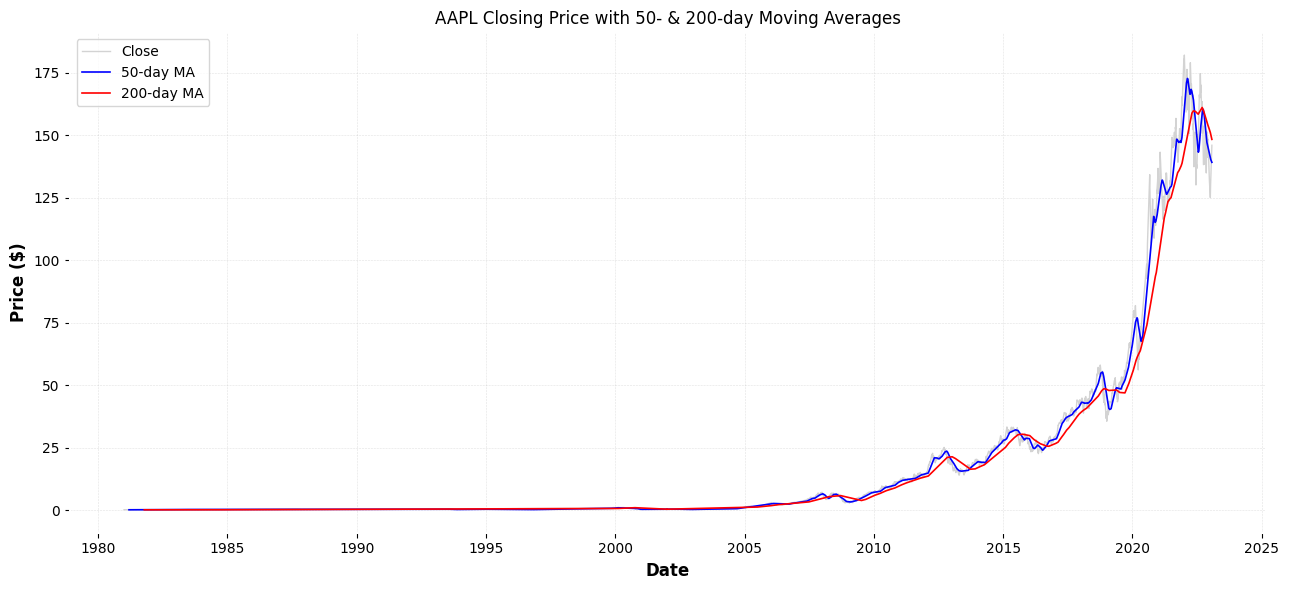

In [7]:
# ── Step 3b: Closing price with moving averages ───────────────
import matplotlib.pyplot as plt

# 50-day and 200-day moving averages — the two most common in finance
df["MA50"]  = df["Close"].rolling(window=50).mean()
df["MA200"] = df["Close"].rolling(window=200).mean()

plt.figure(figsize=(13, 6))
plt.plot(df.index, df["Close"], color="lightgray", linewidth=1, label="Close")
plt.plot(df.index, df["MA50"],  color="blue",  linewidth=1.2, label="50-day MA")
plt.plot(df.index, df["MA200"], color="red",   linewidth=1.2, label="200-day MA")
plt.title("AAPL Closing Price with 50- & 200-day Moving Averages")
plt.ylabel("Price ($)"); plt.xlabel("Date")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [8]:
# ── Step 4a: t-test comparing closing prices across two years ──
from scipy import stats

# Pick two years to compare (edit these if you like)
year_a, year_b = 2021, 2022

close_a = df.loc[df.index.year == year_a, "Close"]
close_b = df.loc[df.index.year == year_b, "Close"]

print(f"{year_a}: n={len(close_a)}, mean=${close_a.mean():.2f}")
print(f"{year_b}: n={len(close_b)}, mean=${close_b.mean():.2f}")

# Welch's t-test (does NOT assume equal variances — safer default)
t_stat, p_value = stats.ttest_ind(close_a, close_b, equal_var=False)

print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\n→ p < {alpha}: the difference in mean closing price between "
          f"{year_a} and {year_b} is statistically significant.")
else:
    print(f"\n→ p ≥ {alpha}: no statistically significant difference "
          f"between {year_a} and {year_b}.")

2021: n=252, mean=$140.99
2022: n=251, mean=$154.84

t-statistic: -11.1866
p-value:     0.000000

→ p < 0.05: the difference in mean closing price between 2021 and 2022 is statistically significant.


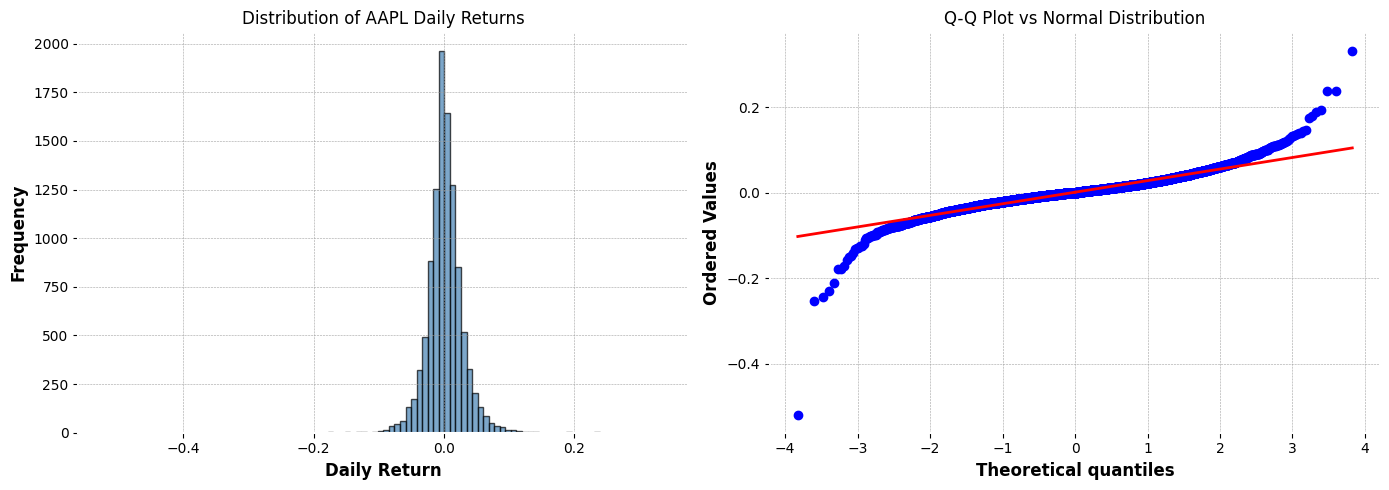

=== Daily returns summary ===
Mean:     0.00105
Std dev:  0.02824
Skew:     -0.3753
Kurtosis: 18.1343  (normal = 0)

Shapiro-Wilk: stat=0.9532, p=0.000000
D'Agostino-Pearson: stat=2719.2053, p=0.000000

→ p < 0.05: daily returns are NOT normally distributed.


In [9]:
# ── Step 4b: daily returns + normality test ───────────────────
import matplotlib.pyplot as plt
from scipy import stats

# Daily return = % change in close from one day to the next
df["daily_return"] = df["Close"].pct_change()
returns = df["daily_return"].dropna()

# --- Visualize the distribution ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(returns, bins=100, color="steelblue", edgecolor="black", alpha=0.7)
ax1.set_title("Distribution of AAPL Daily Returns")
ax1.set_xlabel("Daily Return"); ax1.set_ylabel("Frequency")

# Q-Q plot: points on the line = normal; curved tails = non-normal
stats.probplot(returns, dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot vs Normal Distribution")

plt.tight_layout(); plt.show()

# --- Formal normality tests ---
print("=== Daily returns summary ===")
print(f"Mean:     {returns.mean():.5f}")
print(f"Std dev:  {returns.std():.5f}")
print(f"Skew:     {returns.skew():.4f}")
print(f"Kurtosis: {returns.kurt():.4f}  (normal = 0)")

# Shapiro-Wilk is limited to 5000 samples, so sample if larger
sample = returns.sample(5000, random_state=42) if len(returns) > 5000 else returns
shapiro_stat, shapiro_p = stats.shapiro(sample)
print(f"\nShapiro-Wilk: stat={shapiro_stat:.4f}, p={shapiro_p:.6f}")

# D'Agostino-Pearson uses the full dataset
dag_stat, dag_p = stats.normaltest(returns)
print(f"D'Agostino-Pearson: stat={dag_stat:.4f}, p={dag_p:.6f}")

if shapiro_p < 0.05:
    print("\n→ p < 0.05: daily returns are NOT normally distributed.")
else:
    print("\n→ p ≥ 0.05: cannot reject normality.")

In [10]:
# ── Optional: findings summary ────────────────────────────────
print("="*55)
print("AAPL ANALYSIS — KEY FINDINGS")
print("="*55)
print(f"""
DATA
  Period:        {df.index.min().date()} → {df.index.max().date()}
  Trading days:  {len(df):,}
  Missing values: none

PRICE
  Mean close:    ${df['Close'].mean():.2f}
  Median close:  ${df['Close'].median():.2f}
  All-time high: ${df['Close'].max():.2f}
  All-time low:  ${df['Close'].min():.2f}
  → Mean > median confirms strong right-skew (exponential growth)

HYPOTHESIS TESTS
  1) Mean close 2021 (${df.loc[df.index.year==2021,'Close'].mean():.2f})
     vs 2022 (${df.loc[df.index.year==2022,'Close'].mean():.2f})
     → significant difference (p < 0.001)

  2) Daily returns normality:
     kurtosis = {df['Close'].pct_change().kurt():.1f} (normal = 0) → fat tails
     → returns are NOT normal (p < 0.001)
     → markets have more extreme days than a normal model predicts
""")

AAPL ANALYSIS — KEY FINDINGS

DATA
  Period:        1981-01-02 → 2023-01-27
  Trading days:  10,608
  Missing values: none

PRICE
  Mean close:    $16.70
  Median close:  $0.49
  All-time high: $182.01
  All-time low:  $0.05
  → Mean > median confirms strong right-skew (exponential growth)

HYPOTHESIS TESTS
  1) Mean close 2021 ($140.99)
     vs 2022 ($154.84)
     → significant difference (p < 0.001)

  2) Daily returns normality:
     kurtosis = 18.1 (normal = 0) → fat tails
     → returns are NOT normal (p < 0.001)
     → markets have more extreme days than a normal model predicts

